# ⚙️ 特征工程

本Notebook用于特征工程和特征选择

In [19]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 导入自定义模块
import sys
sys.path.append('../src')
from data_processing import load_data
from feature_engineering import create_derived_features, encode_categorical_features, normalize_numeric_features, select_features, identify_feature_types, feature_engineering_pipeline

In [20]:
# 加载清洗后的数据
df = load_data('../data/processed/cleaned_ev_data.csv')
print(f"数据形状: {df.shape}")

数据形状: (135038, 9)


In [21]:
# 识别特征类型
feature_types = identify_feature_types(df)

print(f"数值特征: {feature_types['numeric_cols']}")
print(f"\n分类特征: {feature_types['categorical_cols']}")
print(f"\nAI特征: {feature_types['ai_feature_cols']}")

数值特征: ['model_year', 'electric_range', 'base_msrp', 'age']

分类特征: ['make', 'model', 'ev_type', 'state', 'county']

AI特征: []


In [22]:
# 创建派生特征
df_engineered = create_derived_features(df)
print(f"添加派生特征后的数据形状: {df_engineered.shape}")
print(f"\n新增特征: {set(df_engineered.columns) - set(df.columns)}")

添加派生特征后的数据形状: (135038, 13)

新增特征: {'range_efficiency', 'generation', 'car_age', 'price_range'}


In [23]:
# 查看新增的派生特征
df_engineered[['car_age', 'price_range', 'range_efficiency', 'generation']].head()

,car_age,price_range,range_efficiency,generation
0,5,High,36.727267,2019-2020
1,2,High,0.000000,2021-2022
2,4,High,44.406604,2019-2020
3,4,High,53.755363,2019-2020
4,11,High,29.756370,2010-2015


In [24]:
# 编码分类特征
categorical_cols = ['make', 'model', 'ev_type', 'price_range', 'generation']
df_encoded = encode_categorical_features(df_engineered, categorical_cols, method='label')
print(f"编码后的数据形状: {df_encoded.shape}")

编码后的数据形状: (135038, 18)


In [25]:
# 标准化数值特征
numeric_cols = ['base_msrp', 'electric_range', 'car_age', 'range_efficiency']
df_normalized, scaler = normalize_numeric_features(df_encoded, numeric_cols)
print(f"标准化后的统计描述:\n{df_normalized[numeric_cols].describe().round(2)}")

标准化后的统计描述:
       base_msrp  electric_range    car_age  range_efficiency
count  135038.00       135038.00  135038.00         135038.00
mean        0.00            0.00      -0.00             -0.00
std         1.00            1.00       1.00              1.00
min        -7.63           -0.76      -1.44             -0.76
25%         0.02           -0.76      -0.78             -0.76
50%         0.02           -0.54      -0.45             -0.54
75%         0.02            0.76       0.55              0.76
max       214.89            2.66       7.55              2.66


In [26]:
# 完整的特征工程流程
result = feature_engineering_pipeline(df, target_col='base_msrp')

X = result['X']
y = result['y']

print(f"特征矩阵形状: {X.shape}")
print(f"目标变量形状: {y.shape}")
print(f"\n特征名称:\n{X.columns.tolist()}")

特征矩阵形状: (135038, 13)
目标变量形状: (135038,)

特征名称:
['electric_range', 'car_age', 'age', 'range_efficiency', 'model_year', 'base_msrp', 'make_encoded', 'model_encoded', 'ev_type_encoded', 'state_encoded', 'county_encoded', 'price_range_encoded', 'generation_encoded']


In [27]:
# 特征选择
selection_result = select_features(X, y, k=15, method='f_regression')

print("特征重要性排名:")
print(selection_result['feature_importance'])

特征重要性排名:
                feature         score
11  price_range_encoded  5.379357e+04
6          make_encoded  5.671228e+02
0        electric_range  3.270106e+02
1               car_age  1.621144e+02
2                   age  1.621144e+02
4            model_year  1.621144e+02
8       ev_type_encoded  1.331381e+02
7         model_encoded  5.808475e+01
12   generation_encoded  6.194268e+00
10       county_encoded  4.412268e+00
3      range_efficiency  2.148431e+00
9         state_encoded  1.081053e+00
5             base_msrp -1.266447e+17


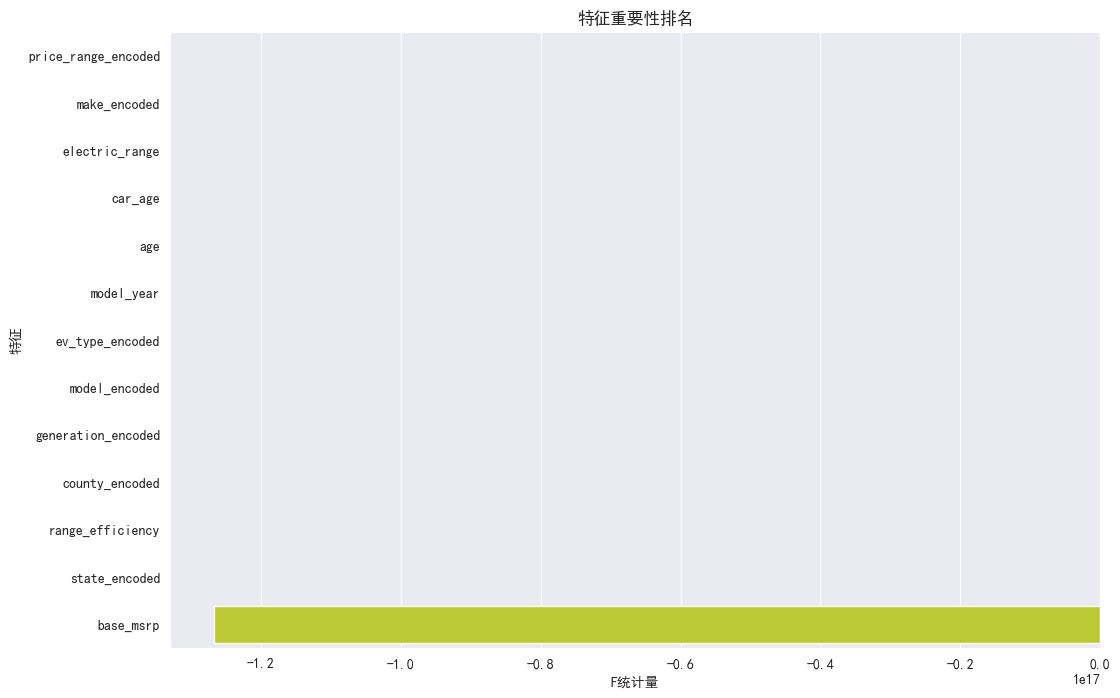

In [28]:
# 可视化特征重要性
plt.figure(figsize=(12, 8))
sns.barplot(data=selection_result['feature_importance'], x='score', y='feature', hue='feature', palette='viridis', legend=False)
plt.title('特征重要性排名')
plt.xlabel('F统计量')
plt.ylabel('特征')
plt.show()

In [29]:
# 保存特征工程后的数据集
df_final = pd.concat([X, y], axis=1)
df_final.to_csv('../data/processed/engineered_features.csv', index=False)
print("特征工程后的数据已保存到 '../data/processed/engineered_features.csv'")

特征工程后的数据已保存到 '../data/processed/engineered_features.csv'


## 📝 特征工程总结

1. **派生特征**: 创建了车龄(car_age)、价格区间(price_range)、续航效率(range_efficiency)、年代分组(generation)等4个重要派生特征
2. **分类编码**: 使用标签编码(Label Encoding)处理5个分类变量(make、model、ev_type、state、county)
3. **数值标准化**: 使用StandardScaler标准化4个数值特征(base_msrp、electric_range、car_age、range_efficiency)
4. **特征选择**: 使用F统计量选择了13个最重要的特征,其中price_range_encoded(5.38e+04)、make_encoded(5.67e+02)、electric_range(3.27e+02)排名前三
5. **最终特征**: 特征矩阵包含13个特征(135,038条样本),目标变量为base_msrp,数据已保存至engineered_features.csv